In [2]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [3]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","TRINITI","SIGLO"]
Nsets = len(datasets)

In [4]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Excitation 1s5 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
True
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
True
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
True
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). M

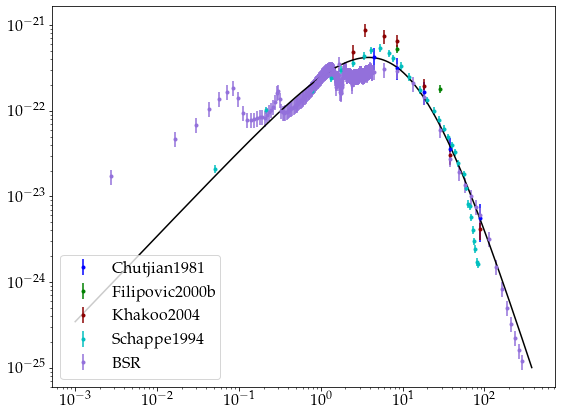

In [11]:
from models import *
level = 1
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        print(swarm.datasets[dataType].error_provided)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
        filename = '%s.1s%d.txt' % (refs[k], 6-level)
        np.savetxt(filename, temp)
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
        
        filename = 'BSR.1s%d.txt' % (6-level)
        np.savetxt(filename, temp)

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([51.2e0,2.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


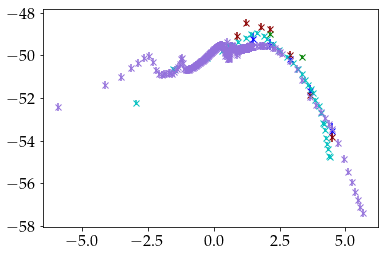

In [43]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [37]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([51.2e0, 2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [44]:
import emcee
nwalkers = 32
theta_ref = np.array([51.2e0,2.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [45]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  5%|██▌                                                  | 24/500 [00:01<00:19, 23.89it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_86152/3735580568.py:36: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
100%|████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.58it/s]


[25.98649054 32.10418985 32.84517431 40.55924156]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.02it/s]


[34.20319977 38.95186921 49.01078989 48.59042745]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.19it/s]


...

[46.92585702 46.15473499 64.29574491 52.92311892]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.54it/s]


[48.27087783 46.3402365  64.99151639 52.37141636]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.43it/s]


[48.3037314  48.00901398 63.97335454 52.51608816]


(6496, 4)


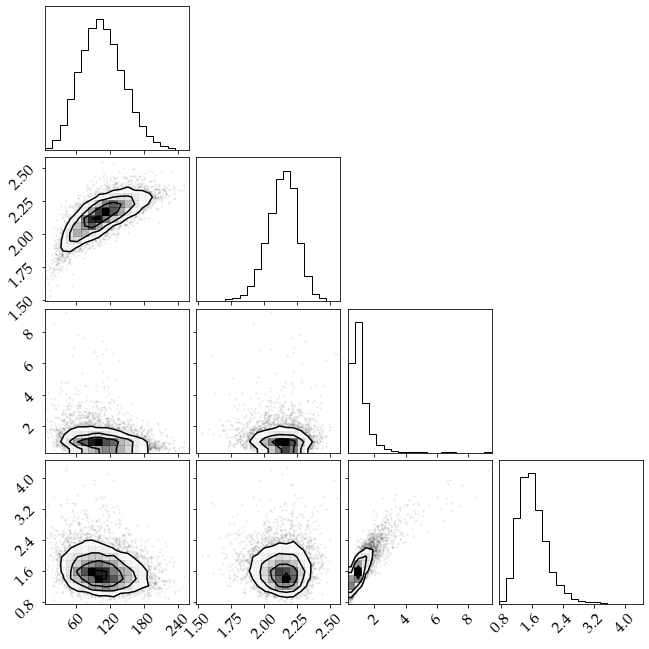

In [46]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
# tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s5.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)

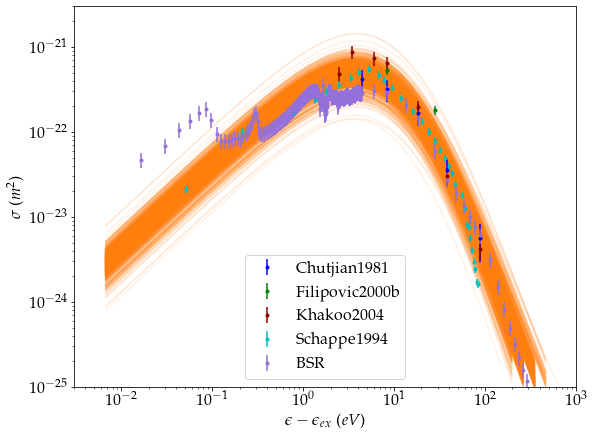

In [6]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s5.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
#     models = Excite_resonance_modified(level,sample[:2],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s5.curve.pdf", dpi=1200)

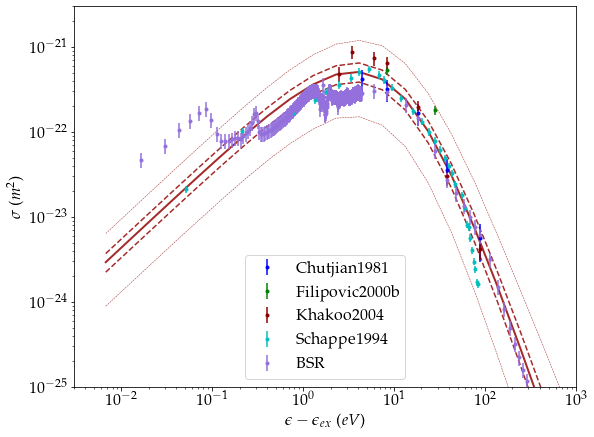

In [7]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s5.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

Nsample, Nw = flat_samples.shape[0], 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
sample_curves = np.zeros([Nsample, Nw])
sig1 = int(np.floor(Nsample * 0.5 * (1.0 - 0.68)))
sig3 = int(np.floor(Nsample * 0.5 * (1.0 - 0.997)))
median = int(np.floor(Nsample * 0.5))

for ind in range(Nsample):
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
    sample_curves[ind,:] = models

sample_sort = np.copy(sample_curves)
sample_sort.sort(axis=0)

plt.figure(1)
plt.loglog(Etest-E_ext[level-1], sample_sort[sig1,:], '--', linewidth=1.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[-sig1,:], '--', linewidth=1.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[sig3,:], '--', linewidth=0.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[-sig3,:], '--', linewidth=0.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[median,:], '-', linewidth=2.0, color='brown')
    
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.pdf", dpi=1200)

temp = np.zeros([Nw,6])
temp[:,0] = Etest
temp[:,1] = sample_sort[median,:]
temp[:,2] = sample_sort[sig1,:]
temp[:,3] = sample_sort[-sig1,:]
temp[:,4] = sample_sort[sig3,:]
temp[:,5] = sample_sort[-sig3,:]
filename = './1s%d.sample_crs.txt' % ((6-level))
np.savetxt(filename, temp)